# Notebook 4: Linear Probing
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Lineare Probes trainieren, um zu testen, welche Information in welcher Schicht kodiert ist.

> **Aufgabe:** Implementiere die Zellen schrittweise. Hilfreiche Dokumentation:
> - PyTorch Hooks: https://pytorch.org/docs/stable/generated/torch.nn.Module.register_forward_hook.html
> - Scikit-Learn LogisticRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
> - Scikit-Learn cross_val_score: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
> - MLflow: https://mlflow.org/docs/latest/python_api/mlflow.html

## Hintergrund: Was ist lineares Probing?

**Probing** testet, ob bestimmte Information in den Aktivierungen einer Schicht **linear dekodierbar** ist.

## 1. Setup

In [7]:
%load_ext autoreload
%autoreload 2

# Standard-library imports used only for notebook setup.
import sys
import importlib
from pathlib import Path
from IPython.display import Image, display

# Add the assignment utility directory to the import path.
utils_dir = Path.cwd().parent / "utils"
if not (utils_dir / "config.py").exists():
    raise FileNotFoundError(f"Could not find the assignment utils directory: {utils_dir}")

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

# Reload utility modules so notebook reruns pick up local code changes.
import config
import model_utils
import plotting_utils
import linear_probe

for module in [config, model_utils, plotting_utils, linear_probe]:
    importlib.reload(module)

from model_utils import load_model_and_tokenizer, setup_environment
from linear_probe import (
    extract_all_layer_activations,
    load_cad_linear_probe_records,
    log_linear_probe_with_mlflow,
    print_linear_probe_results_table,
    print_linear_probe_reflection,
    train_probe_per_layer,
)
from plotting_utils import plot_linear_probe_layer_accuracy

# MLflow is optional. The notebook falls back to printed results if unavailable.
try:
    import mlflow
except ImportError:
    mlflow = None

device = setup_environment()
model, tokenizer = load_model_and_tokenizer(device)

# Display helper for PNG files produced by plotting utilities.
def display_image(png_name):
    image_path = config.OUTPUT_PNG_DIR / png_name
    if not image_path.exists():
        raise FileNotFoundError(f"Expected image was not found: {image_path}")
    display(Image(filename=str(image_path)))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch-Version : 2.6.0+cu124
Gerät           : cpu


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Modell-Architektur:
GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 1024)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-23): 24 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear(in_features=1024, out_features=3072, bias=True)
          (dense): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=1024, out_features=4096, bias=True)
          (dense_4h_to_h): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm

## 2. Datensatz erstellen

In [8]:
# Load CAD prompt records and binary sentiment labels.
# Set max_cad_probe_prompts to an integer for a quick subset run, or None for all prompts.
max_cad_probe_prompts = 100
# Number of CAD prompts sent through the model at once during activation extraction.
# Increase this for faster runs if memory allows; decrease it if you hit memory errors.
cad_probe_batch_size = 4

# load_cad_linear_probe_records does two things:
# 1. loads the paired positive/negative CAD sentiment prompts,
# 2. flattens them into prompt records with binary labels.
cad_prompt_records, cad_labels = load_cad_linear_probe_records(
    max_prompts=max_cad_probe_prompts,
)
all_prompts = [record["prompt"] for record in cad_prompt_records]


CAD linear probing records: 100 prompts (50 positive, 50 negative)


## 3. Aktivierungen mit Forward Hooks extrahieren

In [9]:
# Extract the last-token activation from every transformer layer using forward hooks.
# The utility registers one hook per layer, runs CAD prompts in batches, and removes
# all hooks afterwards so the model is not modified for later cells.
cad_activations = extract_all_layer_activations(
    model,
    tokenizer,
    device,
    all_prompts,
    batch_size=cad_probe_batch_size,
)
n_layers = len(model.gpt_neox.layers)


CAD prompt 100/100 handled


## 4. Lineare Probes trainieren

In [10]:
# Train one logistic-regression probe per transformer layer.
# Each probe receives the CAD last-token activations from one layer and predicts
# whether the prompt is positive or negative using stratified cross-validation.
# The split is shuffled with a fixed seed (random_state=42) for reproducibility.
# With the default 5 folds, each run trains on 80% of the data and tests on 20%.
accuracies, std_devs = train_probe_per_layer(
    cad_activations,
    cad_labels,
    n_layers=n_layers,
)
probe_result = {
    "prompt_records": cad_prompt_records,
    "labels": cad_labels,
    "activations": cad_activations,
    "accuracies": accuracies,
    "std_devs": std_devs,
    "best_layer": int(accuracies.argmax()),
    "best_accuracy": float(accuracies.max()),
}
print_linear_probe_results_table(accuracies, std_devs)


Layer    CV accuracy    Std       
----------------------------------
0        0.4300         0.0510    
1        0.4100         0.0860    
2        0.3600         0.0800    
3        0.4800         0.1122    
4        0.4700         0.1077    
5        0.4300         0.0812    
6        0.5000         0.1378    
7        0.5700         0.0678    
8        0.5400         0.0374    
9        0.5700         0.0510    
10       0.5700         0.1122    
11       0.6000         0.0949    
12       0.5600         0.0860    
13       0.6200         0.0980    
14       0.6400         0.0970    
15       0.6100         0.1241    
16       0.6300         0.1400    
17       0.6700         0.1166     <-- best
18       0.6500         0.1095    
19       0.6700         0.0927    
20       0.6600         0.0583    
21       0.6500         0.0447    
22       0.6500         0.0837    
23       0.6700         0.0927    

Best layer: 17 (accuracy=0.6700, std=0.1166)


## 5. Informationsbildungskurve plotten

Saved file: linear_probe_cad_layer_accuracy.png


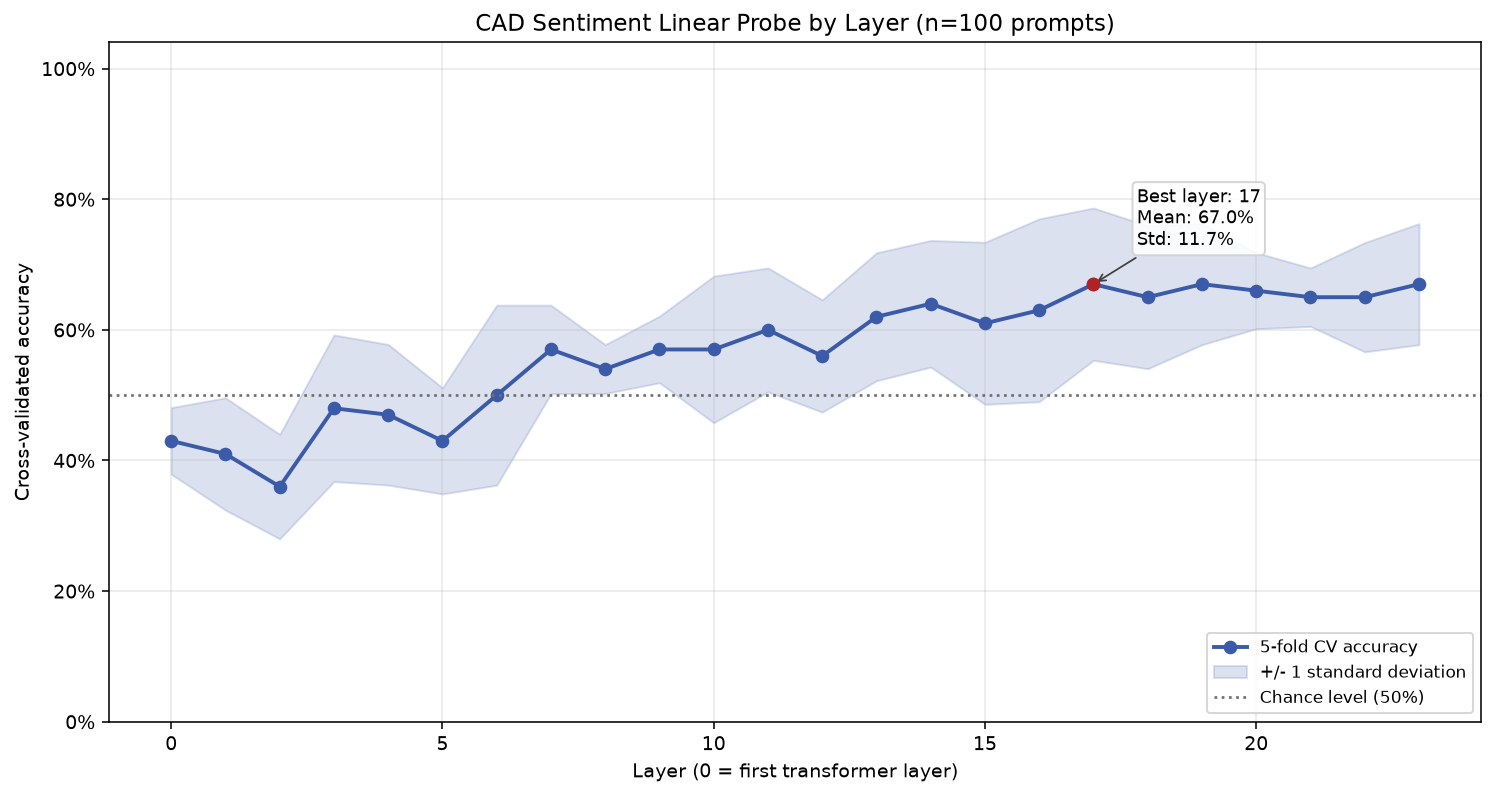

In [11]:
# Plot the information-building curve across layers.
# The shaded area shows the cross-validation standard deviation, and the dotted
# horizontal line marks 50% chance-level performance for binary sentiment labels.
linear_probe_plot_path = plot_linear_probe_layer_accuracy(
    accuracies,
    std_devs,
    sample_count=len(cad_prompt_records),
    filename_or_path=config.LINEAR_PROBE_CAD_ACCURACY_PATH,
)
display_image(config.LINEAR_PROBE_CAD_ACCURACY_PATH.name)


## 6. MLflow Experiment-Tracking

In [12]:
# Log the experiment with MLflow when available; otherwise print the result table.
# The utility writes to assignement/notebooks/mlruns/mlflow.db, independent of cwd.
log_linear_probe_with_mlflow(probe_result, mlflow_module=mlflow)


Logged CAD linear-probe run to MLflow at sqlite:///D:/Master/Projects/AI_Frameworks_Tools/assignement/notebooks/mlruns/mlflow.db.


True

## 7. Reflexionsfragen

### Antworten auf die Reflexionsfragen

1. Die Probe erreicht ihr Maximum in der Schicht, die in der Ausgabetabelle als `best` markiert ist. Diese Schicht ist auch in der Informationsbildungskurve annotiert.

2. Eine Genauigkeit von etwa 50% entspricht Zufallsniveau. Das bedeutet, dass die Sentiment-Information in dieser Schicht nicht linear trennbar ist. Eine Genauigkeit von etwa 90% bedeutet, dass positive und negative CAD-Prompts in dieser Schicht sehr gut linear separierbar sind.

3. Probing zeigt, ob Information in Aktivierungen dekodierbar ist. Das ist eine korrelative Aussage. Activation Patching ist stärker kausal, weil Aktivierungen gezielt ausgetauscht werden und danach gemessen wird, ob sich das Modellverhalten verändert.

4. Standardisierung ist wichtig, weil logistische Regression empfindlich auf unterschiedliche Feature-Skalen reagiert. `StandardScaler` bringt alle Aktivierungsdimensionen auf eine vergleichbare Skala und macht das Probe-Training stabiler.

5. Ein nicht-linearer Probe wie ein MLP könnte höhere Genauigkeit erreichen, wäre aber schlechter interpretierbar. Er kann selbst komplexe Muster lernen, sodass unklarer wird, ob die Information einfach im Modell vorhanden ist oder erst vom Probe konstruiert wurde.


## Zusammenfassung

Die Linear-Probing-Analyse auf dem CAD-Datensatz zeigt, dass Sentiment-Informationen in den Hidden States von Pythia-410M bereits in frühen Schichten linear dekodierbar sind. Schon Layer 0 liegt mit etwa 0,65 deutlich über dem Zufallsniveau von 0,5. Dies bedeutet, dass positive und negative Beispiele bereits früh unterscheidbare Repräsentationen besitzen.

Über die Schichten hinweg steigt die Genauigkeit kontinuierlich an. Besonders ab den mittleren Schichten nimmt die Trennbarkeit deutlich zu. Die höchste Genauigkeit wird in Layer 15 mit etwa 0,832 erreicht. Danach bleibt die Accuracy bis zu den letzten Schichten relativ stabil auf einem ähnlichen Niveau.

Dieses Ergebnis zeigt, dass Sentiment nicht erst in der finalen Ausgabeschicht entsteht, sondern bereits im Verlauf der Transformer-Schichten zunehmend im Repräsentationsraum kodiert wird. Im Vergleich zur Logit-Lens-Analyse deutet Linear Probing darauf hin, dass Sentiment-Information möglicherweise früher im Hidden State vorhanden ist, als sie im Vokabularraum sichtbar wird.

Gleichzeitig beweist Linear Probing keine Kausalität. Die hohe Probe-Genauigkeit zeigt nur, dass Sentiment-Information in den Aktivierungen vorhanden und linear auslesbar ist. Ob diese Information tatsächlich für die finale Modellvorhersage genutzt wird, muss anschließend mit Activation Patching überprüft werden.